## Load in test data
Load in the 1D PES for the POH bending angle.

In [1]:
#Code cell adapted from 1d_energy_comparison.ipynb in the pvqz_basis_set_comparison folder
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
from scipy.optimize import curve_fit
hartree_to_cm = 219474.63

def load_coords_energy(file_name):
    """loads in unsorted basis set energy files"""
    #sort file by coordinates first
    energy_file = np.loadtxt(file_name)
    sort_idx = np.argsort(energy_file[:,7])
    energy_file = energy_file[sort_idx]
    
    #convert hartree to wavenumber, set minimum
    energy_file[:,6] = energy_file[:,6]*hartree_to_cm
    energy_file[:,6] = energy_file[:,6] - min(energy_file[:,6])
    
    #separate coords and energy
    return (energy_file[:,:6], energy_file[:,6])

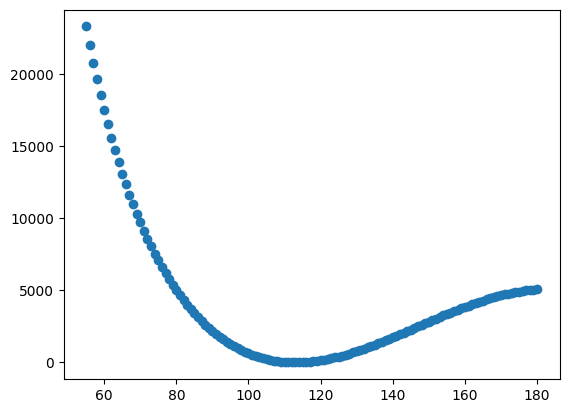

In [2]:
apoh_coords, E_apoh = load_coords_energy('apoh_1d.txt')
apoh = apoh_coords[:,4]*np.pi/180
w = (np.tanh(-0.008*(E_apoh - 2000)) + 1.002002002) / 2.002002002
#print(apoh)
#print(E_apoh)

plt.figure()
plt.plot(apoh*180/np.pi, E_apoh, 'o')
#plt.xlim(100,130)
#plt.ylim(-0.5, 1000)

## Reproduce original fits

Older fits have functional forms similar or close to a taylor expansion of the cos term:

$$ \cos(x) - \cos(x_e) $$

Often the fit is $ \cos(x_e) - \cos(x) $ since we instead fit $\rho = \pi - \beta $ instead of the actual bending angle $ \beta $. RMSD is around 0.9cm-1 weighted.

In [3]:
def power_term(x, xe):
    #return np.cos(x) - np.cos(xe)
    return x - xe

def cos_term(x, xe):
    return np.cos(x) - np.cos(xe)

def power_series(x, xe, c0, c1, c2, c3, c4, c5, c6, c7, c8):
    z = power_term(x, xe)
    c = [c0, c1, c2, c3, c4, c5, c6, c7, c8]
    series = 0
    for i in range(9):
        series += c[i]*z**(i)

    return series 

def cos_series(x, xe, c0, c1, c2, c3, c4, c5, c6, c7, c8):
    z = cos_term(x, xe)
    c = [c0, c1, c2, c3, c4, c5, c6, c7, c8]
    series = 0
    for i in range(9):
        series += c[i]*z**(i)

    return series 

def rmsd(obs, calc, weight):
    squared_diff = (obs-calc)**2
    weighted_mean_sqr = np.sum(weight*squared_diff)/np.sum(weight)
    return np.sqrt(weighted_mean_sqr)

def fit_evaluation(function, param_guess, weights):
    """This function fits a function to the bending energy data with given
       input parameters and given weights. Uses SciPy curvefit"""
    
    #perform fit
    p, cov = curve_fit(function, apoh, E_apoh, 
                       param_guess, 
                       sigma = 1/np.sqrt(weights))
    
    #print parameters obtained from fit
    print('Parameter Values:')
    print(np.round(p, 5))
    print()
    print('Parameter Error (%)')
    print(np.round(
    (np.sqrt(np.diag(cov))/p*100),
     3))
    
    #unpack parameters to predict energy, print RMSD 
    function_predict = function(apoh, *p)
    print()
    print(f'The RMSD is {rmsd(E_apoh, function_predict, weights)} cm-1')
    print()

    #print residuals
    with np.printoptions(precision=3, suppress=True, linewidth=100):
        print('Residuals:')
        print(E_apoh - function_predict)
    #leave space for plotting
    for i in range(3):
        print()
    #plot fit, calculations and residuals
    plt.figure()
    plt.plot(apoh*180/np.pi, function_predict)
    plt.plot(apoh*180/np.pi, E_apoh, '.')

    plt.figure()
    plt.plot(apoh*180/np.pi, E_apoh - function_predict)
    


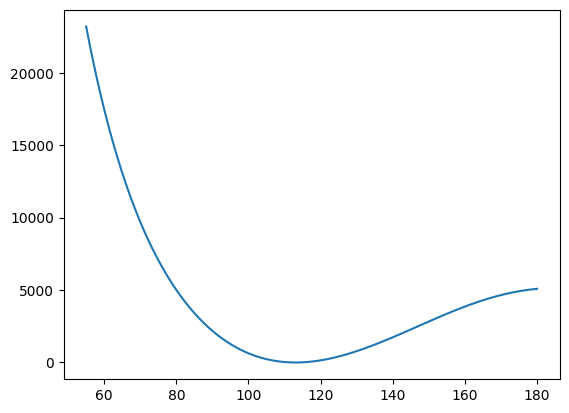

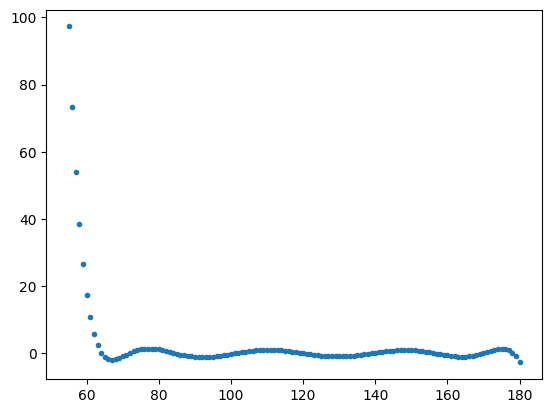

In [4]:
w = (np.tanh(-0.008*(E_apoh - 16000)) + 1.002002002) / 2.002002002
original_params = [1.974, -0.91334819, 10764.035, -6290.1980, 526.76432, -1098.6327, 
                   1669.8193, -1398.7498, 502.39223]

original_fit = power_series(apoh, 113.04244011*np.pi/180,
                          -0.91334819,
                          0,
                          10764.035, 
                          -6290.1980, 
                          526.76432, 
                          -1098.6327, 
                          1669.8193, 
                          -1398.7498, 
                          502.39223)

plt.figure()
plt.plot(apoh*180/np.pi, original_fit)

plt.figure()
plt.plot(apoh*180/np.pi, E_apoh - original_fit, '.')

In [5]:
print(f'The RMSD is {rmsd(E_apoh, original_fit, w)} cm-1')
print()

with np.printoptions(precision=3, suppress=True, linewidth=100):
    print('Residuals:')
    print(E_apoh - original_fit)


The RMSD is 1.1086512355151292 cm-1

Residuals:
[97.293 73.183 53.827 38.505 26.575 17.467 10.678  5.771  2.368  0.145 -1.173 -1.815 -1.972 -1.799
 -1.419 -0.931 -0.407  0.097  0.543  0.906  1.174  1.341  1.411  1.391  1.293  1.13   0.918  0.671
  0.405  0.132 -0.134 -0.384 -0.608 -0.8   -0.954 -1.067 -1.138 -1.166 -1.153 -1.102 -1.015 -0.898
 -0.756 -0.594 -0.418 -0.234 -0.047  0.136  0.311  0.473  0.618  0.743  0.846  0.923  0.974  0.997
  0.994  0.963  0.907  0.828  0.728  0.609  0.475  0.329  0.176  0.019 -0.137 -0.289 -0.433 -0.565
 -0.682 -0.781 -0.859 -0.914 -0.946 -0.953 -0.935 -0.892 -0.825 -0.737 -0.629 -0.504 -0.366 -0.217
 -0.062  0.095  0.25   0.398  0.536  0.658  0.761  0.842  0.897  0.925  0.922  0.89   0.826  0.733
  0.611  0.465  0.298  0.115 -0.077 -0.272 -0.461 -0.637 -0.791 -0.914 -0.996 -1.032 -1.013 -0.936
 -0.797 -0.599 -0.345 -0.047  0.282  0.616  0.925  1.168  1.291  1.23   0.902  0.212 -0.959 -2.748]


Now we test whether the SciPy fitting function can reproduce the fit provided by the Fortran program.

Parameter Values:
[ 1.97289000e+00 -1.01022000e+00  1.07675408e+04 -6.30946983e+03
  5.24490640e+02 -1.04242543e+03  1.65202775e+03 -1.44664680e+03
  5.29805000e+02]

Parameter Error (%)
[ 3.0000e-03 -2.2276e+01  3.2000e-02 -1.6300e-01  2.7330e+00 -2.3070e+00
  1.3780e+00 -1.2320e+00  2.7350e+00]

The RMSD is 1.0331297707117009 cm-1

Residuals:
[77.953 57.59  41.411 28.765 19.07  11.812  6.539  2.859  0.433 -1.024 -1.756 -1.963 -1.81  -1.43
 -0.926 -0.379  0.152  0.625  1.012  1.299  1.479  1.554  1.533  1.426  1.247  1.014  0.743  0.448
  0.146 -0.15  -0.429 -0.68  -0.896 -1.07  -1.2   -1.283 -1.318 -1.307 -1.253 -1.16  -1.031 -0.873
 -0.692 -0.494 -0.286 -0.074  0.136  0.337  0.525  0.696  0.844  0.967  1.062  1.128  1.164  1.168
  1.143  1.088  1.005  0.898  0.769  0.622  0.459  0.287  0.108 -0.072 -0.249 -0.42  -0.578 -0.721
 -0.846 -0.948 -1.027 -1.078 -1.103 -1.098 -1.066 -1.006 -0.92  -0.81  -0.678 -0.529 -0.364 -0.19
 -0.01   0.171  0.349  0.517  0.673  0.81   0.924  1.013  1.0

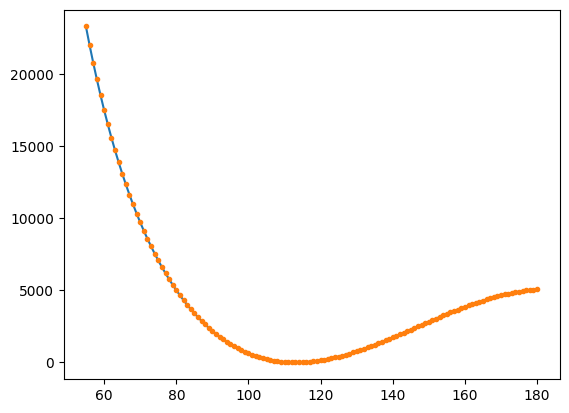

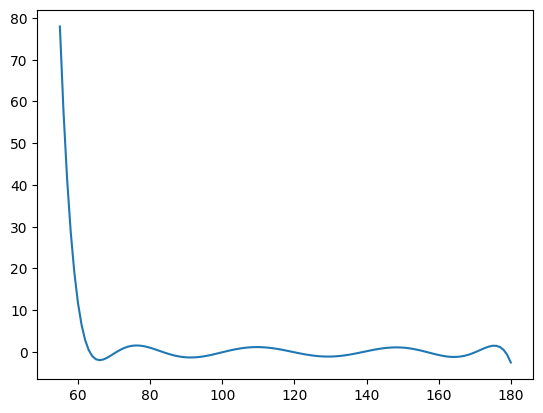

In [6]:
#fortran fit done without linear term
def power_no_linear(x, xe, c0, c2, c3, c4, c5, c6, c7, c8):
    return power_series(x, xe, c0, 0, c2, c3, c4, c5, c6, c7, c8)

power_weight = (np.tanh(-0.008*(E_apoh - 16000)) + 1.002002002) / 2.002002002

fit_evaluation(power_no_linear, original_params, power_weight)

SciPy can reproduce the fit given the initial guess set to the already found linear parameters, we turn our attention to fitting new functional forms.

## New Fits

We now try morse-like fits:
$$ a(1-e^{b(\cos(x)-\cos(x_e))})^2 $$

Parameter Values:
[1.93361000e+00 7.08170066e+04 4.56660000e-01]

Parameter Error (%)
[0.216 8.835 4.304]

The RMSD is 242.30482125080746 cm-1

Residuals:
[3555.613 3001.797 2509.668 2073.981 1689.84  1352.68  1058.251  802.604  582.072  393.257  233.012
   98.431  -13.171 -104.267 -177.136 -233.871 -276.394 -306.466 -325.7   -335.567 -337.409 -332.449
 -321.794 -306.449 -287.322 -265.231 -240.909 -215.014 -188.133 -160.786 -133.432 -106.474  -80.263
  -55.101  -31.247   -8.919   11.703   30.475   47.282   62.039   74.687   85.193   93.544   99.747
  103.828  105.827  105.801  103.819   99.96    94.315   86.982   78.068   67.685   55.95    42.985
   28.915   13.867   -2.03   -18.648  -35.856  -53.527  -71.532  -89.746 -108.044 -126.308 -144.418
 -162.262 -179.729 -196.714 -213.117 -228.841 -243.797 -257.899 -271.068 -283.23  -294.318 -304.269
 -313.028 -320.546 -326.779 -331.69  -335.248 -337.428 -338.211 -337.584 -335.54  -332.078 -327.202
 -320.922 -313.253 -304.214 -293.833 -282.137

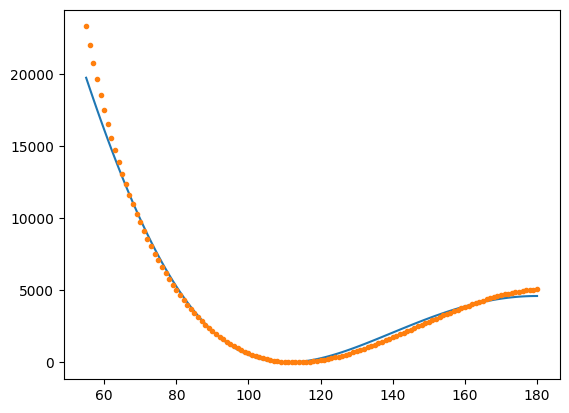

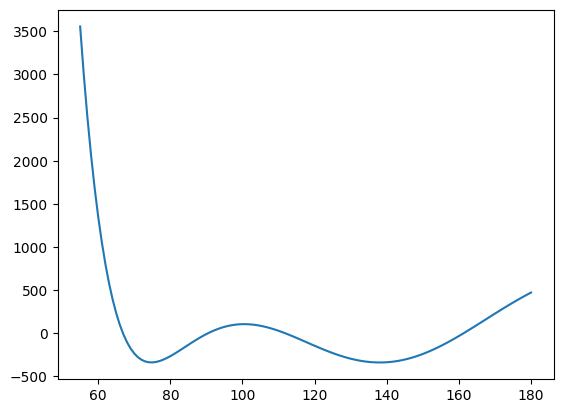

In [7]:
#try fitting only one morse-like term
def morse_like(x, xe, b):
    return 1 - np.exp(b*(np.cos(x)-np.cos(xe)))


weight_morse_test = (np.tanh(-0.008*(E_apoh - 16000)) + 1.002002002) / 2.002002002
fit_evaluation(lambda x, xe, a, b: a*morse_like(x, xe, b)**2, 
               [113.04244011*np.pi/180, 
                10000, 
                0.17], 
                weight_morse_test)



The morse-like cosine term is reasonable, the residuals show there are still additional contributions required which is expected. The converged value of xe seems to be skewed by the asymmetry/higher energy points which puts it slightly offset from the minimum. 

The natural progression is to fit more higher order morse terms or combine with polynomial and cosine terms.

## Try more functional forms

Parameter Values:
[ 1.97286000e+00  2.95801752e+06  2.15830000e-01 -6.11390000e-01
 -1.05940528e+05  6.64804725e+04  1.67903816e+04 -1.93738806e+04
  3.82628858e+03]

Parameter Error (%)
[ 2.0000e-03  1.0420e+00  9.2700e-01 -2.9298e+01 -1.3570e+00  1.6160e+00
  6.2200e-01 -1.2190e+00  1.8000e+00]

The RMSD is 0.8045067370759941 cm-1

Residuals:
[65.427 47.9   34.096 23.411 15.308  9.316  5.026  2.087  0.198 -0.895 -1.401 -1.493 -1.312 -0.966
 -0.541 -0.101  0.309  0.657  0.925  1.104  1.194  1.199  1.129  0.996  0.814  0.596  0.358  0.113
 -0.127 -0.352 -0.553 -0.723 -0.858 -0.955 -1.012 -1.029 -1.009 -0.953 -0.865 -0.75  -0.613 -0.46
 -0.295 -0.125  0.045  0.21   0.365  0.507  0.631  0.734  0.815  0.872  0.904  0.911  0.894  0.853
  0.791  0.708  0.607  0.492  0.365  0.229  0.089 -0.053 -0.192 -0.326 -0.45  -0.563 -0.66  -0.741
 -0.802 -0.842 -0.861 -0.858 -0.833 -0.787 -0.72  -0.635 -0.534 -0.418 -0.291 -0.157 -0.018  0.122
  0.259  0.389  0.51   0.617  0.707  0.779  0.828  0.854  0.

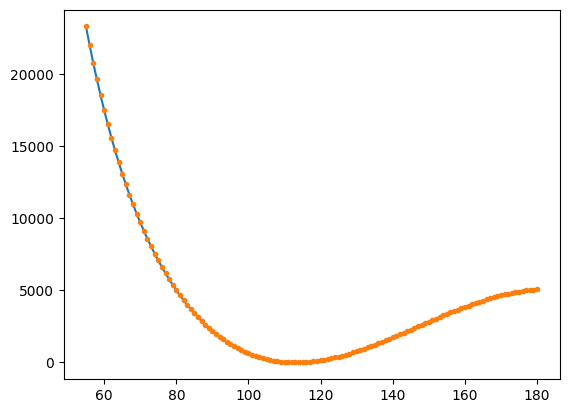

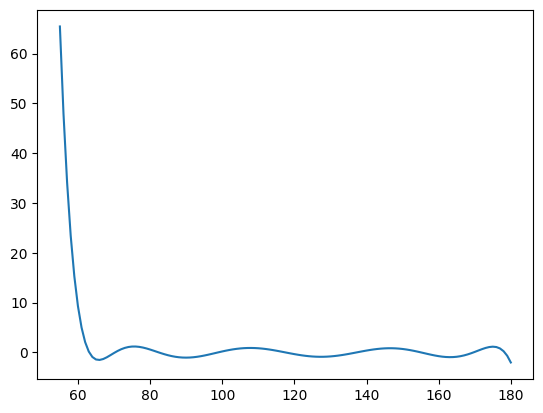

In [8]:
def morse_polynomial(x, xe, a, b, c0, c2, c3, c4, c5, c6):
    series = a*morse_like(x, xe, b)**2
    c = [c0, c2, c3, c4, c5, c6]
    powers = [0, 2, 3, 4, 5, 6]
    for j in range(len(c)):
        series += c[j]*power_term(x, xe)**powers[j]
    return series

weight_morse_poly = (np.tanh(-0.008*(E_apoh - 16000)) + 1.002002002) / 2.002002002
fit_evaluation(morse_polynomial, 
              [113.04244011*np.pi/180, 
               7.08170066e+04, 
               4.56660000e-01,
                        0,
                        0,
                        0,
                        0,
                        0,
                        0],
                weight_morse_poly)

In the above, we fit a function of the form:

$$ a(1-e^{b(\cos(x)-\cos(x_e))})^2 + c_0 + c_2 (x-x_e)^2 + c_3 (x-x_e)^3 + c_4 (x-x_e)^4 + c_5 (x-x_e)^5 + c_6 (x-x_e)^6$$

This achieves a fit marginally better than the polynomial fit. The fit can't extrapolate the left side well (growth is too slow), which suggests higher order morse growth needed. 

Including $x^7$ and $x^8$ terms improved RMSD to 0.456 and the extrapolated fit points reduced in residual - although this was done with the parameter b fixed to the 6th order convergence (otherwise fit did not converge) and parameter error increased.

Parameter Values:
[ 1.96804000e+00 -5.34362000e+00  2.80716544e+05 -1.26439089e+05
 -3.54190377e+05  1.01010634e+07  1.59479603e+08  2.89956172e+08
  0.00000000e+00]

Parameter Error (%)
[ inf -inf  inf -inf -inf  inf  inf  inf  inf]

The RMSD is 19.530008265230904 cm-1

Residuals:
[569.892 420.799 302.219 209.46  138.334  85.122  46.548  19.753   2.259  -8.058 -12.998 -14.069
 -12.513  -9.333  -5.327  -1.106   2.878   6.309   8.986  10.804  11.734  11.81   11.11    9.747
   7.853   5.572   3.053   0.439  -2.137  -4.555  -6.713  -8.527  -9.934 -10.893 -11.383 -11.399
 -10.958 -10.09   -8.841  -7.265  -5.428  -3.4    -1.255   0.932   3.088   5.141   7.027   8.689
  10.076  11.149  11.877  12.241  12.233  11.854  11.117  10.043   8.664   7.018   5.15    3.111
   0.956  -1.258  -3.471  -5.624  -7.661  -9.527 -11.172 -12.552 -13.626 -14.365 -14.745 -14.75
 -14.374 -13.62  -12.499 -11.03   -9.243  -7.173  -4.864  -2.365   0.27    2.981   5.707   8.383
  10.946  13.332  15.478  17.327  18.82

C:\Users\ryanm\AppData\Local\Temp\ipykernel_29504\2771796200.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  p, cov = curve_fit(function, apoh, E_apoh,


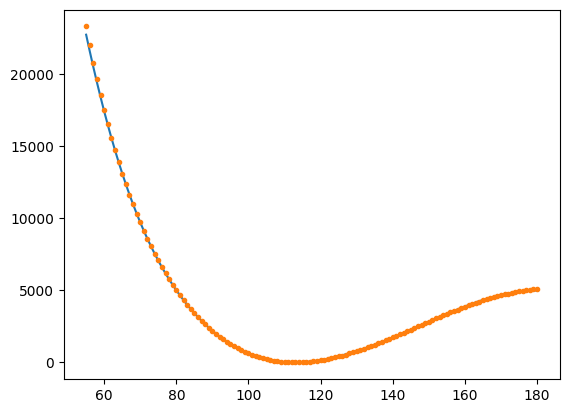

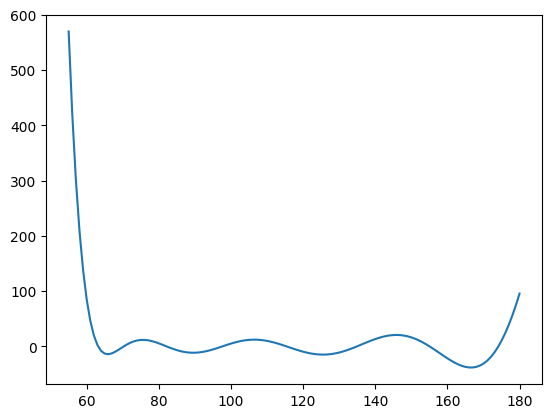

In [12]:
def morse_quartic(x, xe, c0, c2, c3, c4, c5, c6, c7, c8):
    series = c0
    c = [c2, c3, c4, c5, c6, c7, c8]
    powers = [2, 3, 4, 5, 6, 7, 8]
    for j in range(len(c)):
        series += c[j]*morse_like(x, xe, 2.15830000e-01)**powers[j]
    return series

weight_morse_quartic = (np.tanh(-0.008*(E_apoh - 16000)) + 1.002002002) / 2.002002002
fit_evaluation(morse_quartic, 
              [1.98400000e+00,
               1.68051900e+01, 
               1.30691808e+05,
               1.38435356e+05,
               8.67869692e+05,
               0,
               0,
               0,
               0],
                weight_morse_quartic)

Morse terms alone do not represent a good fit well. Fitting also becomes unstable with too many terms. Adding quartic term reduces error on left side of the well. 

Parameter Values:
[ 1.96863000e+00  2.88648958e+06  1.75460000e-01 -4.90666000e+00
 -7.58198699e+04 -1.18384096e+04 -1.32103384e+03 -3.19778874e+03
  1.24360073e+04]

Parameter Error (%)
[ 5.30000000e-02  6.07666241e+05  7.16850000e+04 -9.03600000e+01
 -5.86140799e+05 -5.97661872e+05 -5.00974419e+05 -1.44806210e+04
  2.22641000e+02]

The RMSD is 18.63446713141657 cm-1

Residuals:
[415.721 304.506 216.709 148.583  96.81   58.474  31.026  12.262   0.288  -6.506  -9.47   -9.728
  -8.192  -5.598  -2.518   0.613   3.479   5.865   7.64    8.743   9.169   8.953   8.166   6.899
   5.259   3.358   1.31   -0.776  -2.799  -4.669  -6.31   -7.662  -8.677  -9.326  -9.596  -9.486
  -9.009  -8.193  -7.072  -5.693  -4.107  -2.371  -0.544   1.313   3.14    4.88    6.48    7.891
   9.071   9.987  10.612  10.927  10.924  10.603   9.97    9.043   7.845   6.406   4.764   2.961
   1.043  -0.941  -2.941  -4.904  -6.779  -8.517 -10.073 -11.402 -12.469 -13.241 -13.694 -13.809
 -13.576 -12.993 -12.066 -10.808  -

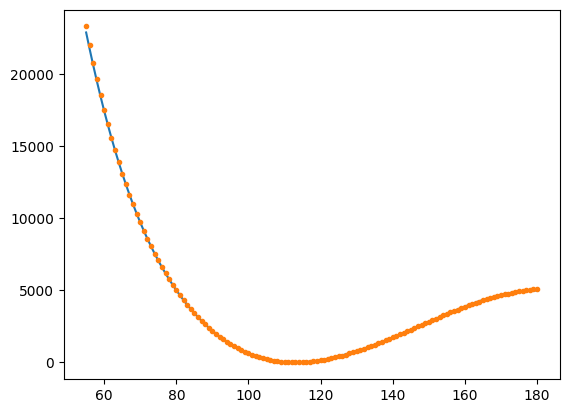

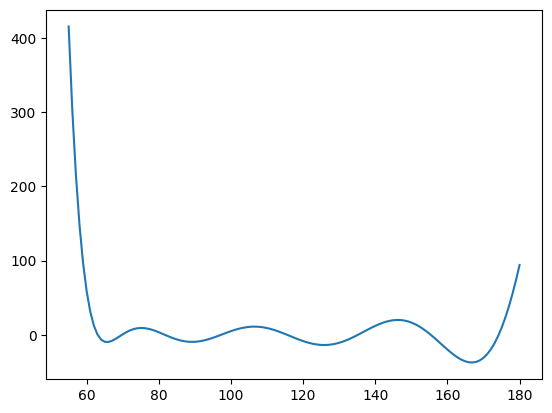

In [25]:
def cosine_morse(x, xe, a, b, c0, c2, c3, c4, c5, c6):
    series = a*morse_like(x, xe, b)**2
    c = [c0, c2, c3, c4, c5, c6]
    powers = [0, 2, 3, 4, 5, 6]
    for j in range(len(c)):
        series += c[j]*cos_term(x, xe)**powers[j]
    return series

weight_cos_morse = (np.tanh(-0.008*(E_apoh - 16000)) + 1.002002002) / 2.002002002
fit_evaluation(cosine_morse, 
              [1.97286000e+00,
               2.95801752e+06,
               2.15830000e-01,
               -6.11390000e-01,
               -1.05940528e+05,
               6.64804725e+04,
               1.67903816e+04,
               -1.93738806e+04,
               3.82628858e+03],
               weight_cos_morse)

The cosine series does not fit as well as the polynomial one. 